# 03 — Modelo, validación temporal, calibración y explicabilidad

Pipeline: `scripts/run_pipeline.py` → `src/repurchase/modelo.py`. Split **temporal** por fecha de scoring: entrenamiento
con ventanas abiertas hasta `train_end`, calibración (isotónica) en el período siguiente, evaluación en ventanas
posteriores cuyo horizonte cerró antes del cutoff. Baselines: azar (prioridad uniforme = situación actual), heurística de
reglas y regresión logística.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)
from IPython.display import Image, Markdown, display
from repurchase import config
from repurchase.eventos import appointments, CUTOFF
from repurchase.io import load_sales, load_agenda
print("cutoff de datos:", CUTOFF.date())

cutoff de datos: 2026-08-25


In [2]:
from repurchase.modelo import LABEL, SplitConfig, run_training
data = pd.read_parquet(config.PROCESSED_DIR / "dataset_analitico.parquet")
cfg = json.loads((ROOT / "config/params.json").read_text(encoding="utf8"))
print("dataset analítico:", data.shape)
res = run_training(data, SplitConfig(**cfg["split"]), out_dir=config.MODELS_DIR / "notebook_run", exclude_snapshot=cfg["modelo"]["exclude_snapshot"])
display(res["metrics"].round(4))
print(json.dumps({k: v for k, v in res["info"].items() if k != "lgb_params"}, indent=2, ensure_ascii=False))

dataset analítico: (142637, 105)


,n,base_rate,roc_auc,pr_auc,brier,log_loss,ece
modelo,,,,,,,
"azar (prioridad uniforme, situación actual)",19709,0.4262,0.4969,0.4224,0.3347,1.0049,0.2553
heurística de reglas,19709,0.4262,0.6093,0.5180,NaN,NaN,NaN
regresión logística (calibrada),19709,0.4262,0.6744,0.5961,0.2222,0.6505,0.0179
LightGBM sin calibrar,19709,0.4262,0.7407,0.7124,0.1985,0.5766,0.0129
LightGBM calibrado (isotónica),19709,0.4262,0.7403,0.7042,0.1985,0.5781,0.0098


{
  "split": {
    "train_end": "2025-09-30",
    "valid_end": "2025-12-31"
  },
  "n_train": 102040,
  "n_valid": 20888,
  "n_test": 19709,
  "base_rate_train": 0.4139749117992944,
  "base_rate_valid": 0.4160283416315588,
  "base_rate_test": 0.4262012278654422,
  "best_iteration": 271,
  "n_features": 86,
  "exclude_snapshot": true,
  "test_scoring_range": [
    "2026-01-01",
    "2026-03-28"
  ]
}


## Curva de ganancia, lift por decil, calibración

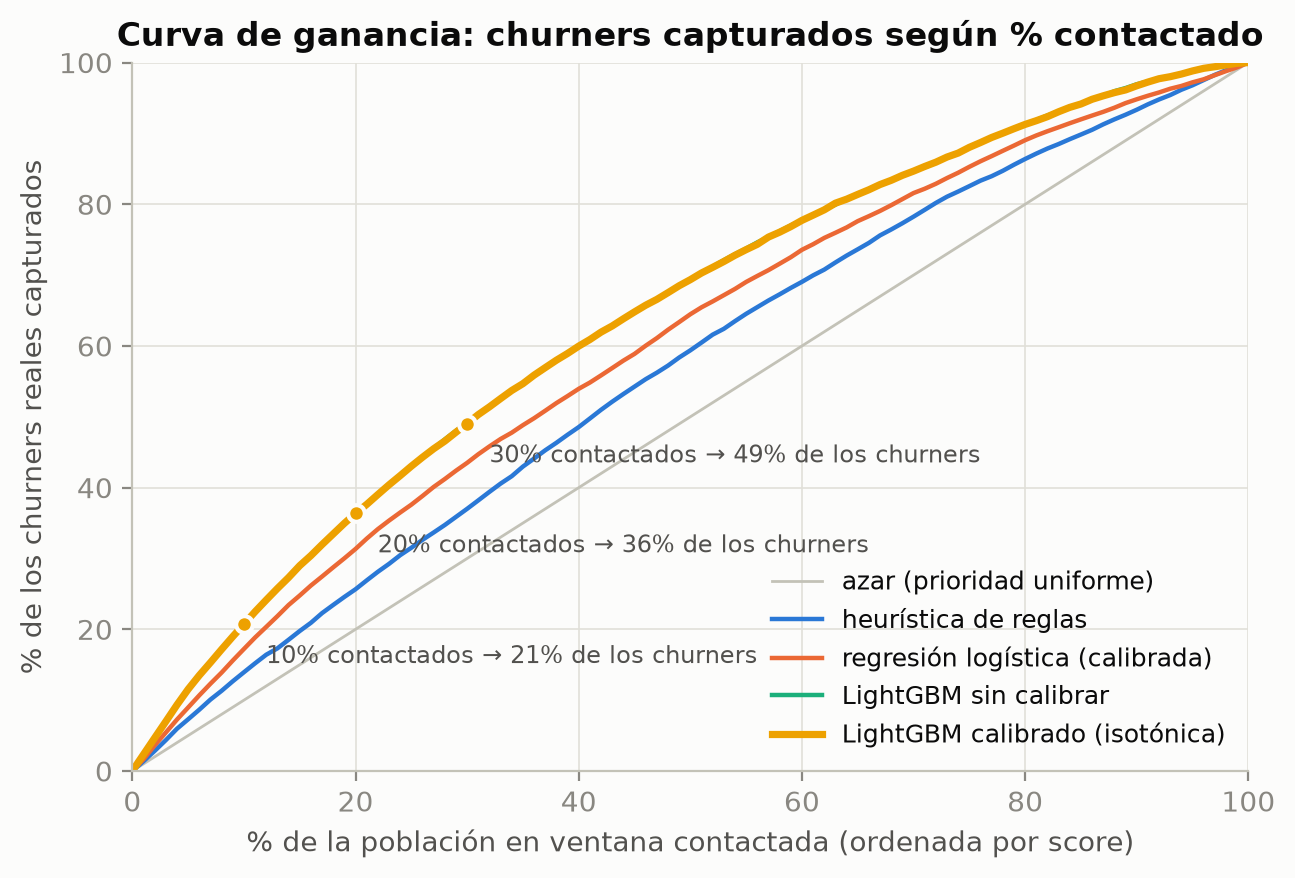

*Contactando al 20 % de mayor score se captura ~36 % de los churners (vs 20 % al azar).*

In [3]:
display(Image(filename=str(ROOT / "reports/figures/modelo/ganancia.png"), width=900)); display(Markdown("*Contactando al 20 % de mayor score se captura ~36 % de los churners (vs 20 % al azar).*"))

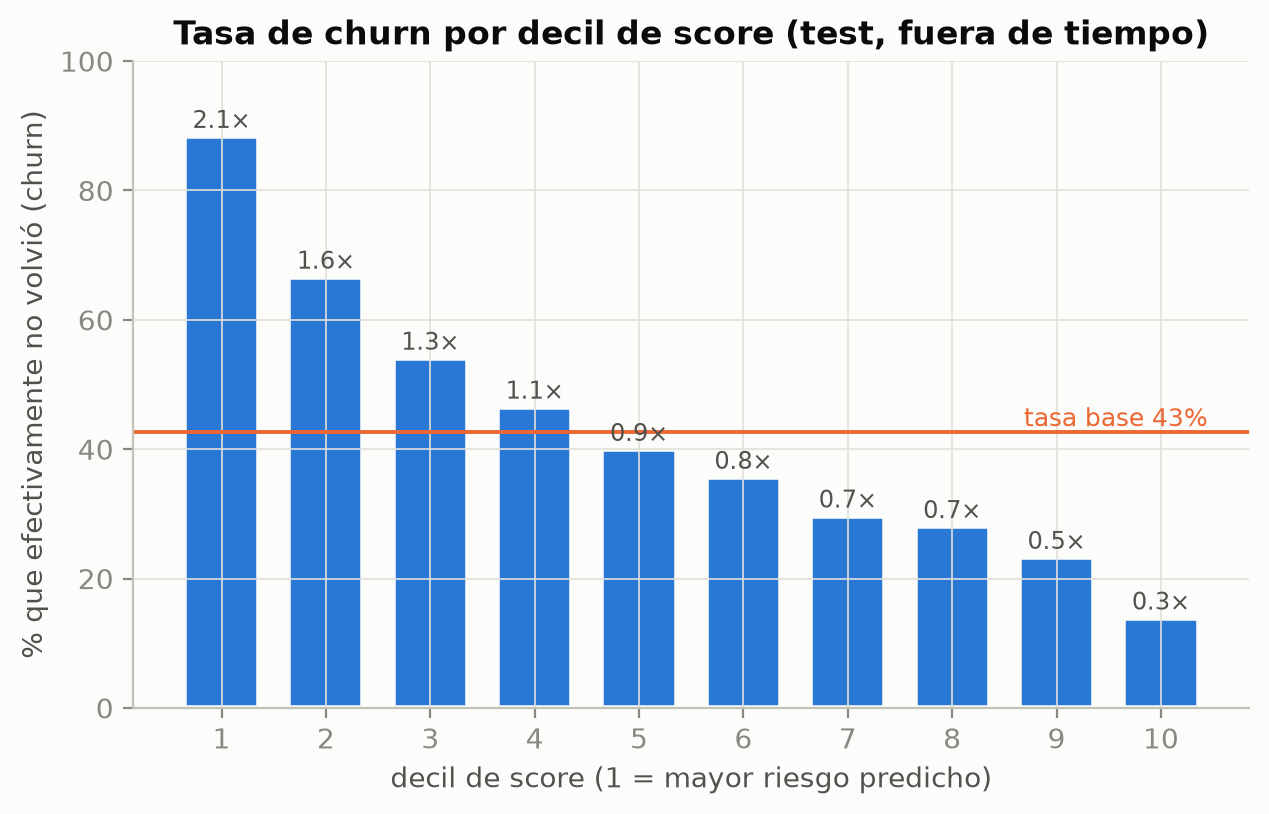

*Tasa de churn observada por decil de score en test.*

In [4]:
display(Image(filename=str(ROOT / "reports/figures/modelo/lift_deciles.png"), width=900)); display(Markdown("*Tasa de churn observada por decil de score en test.*"))

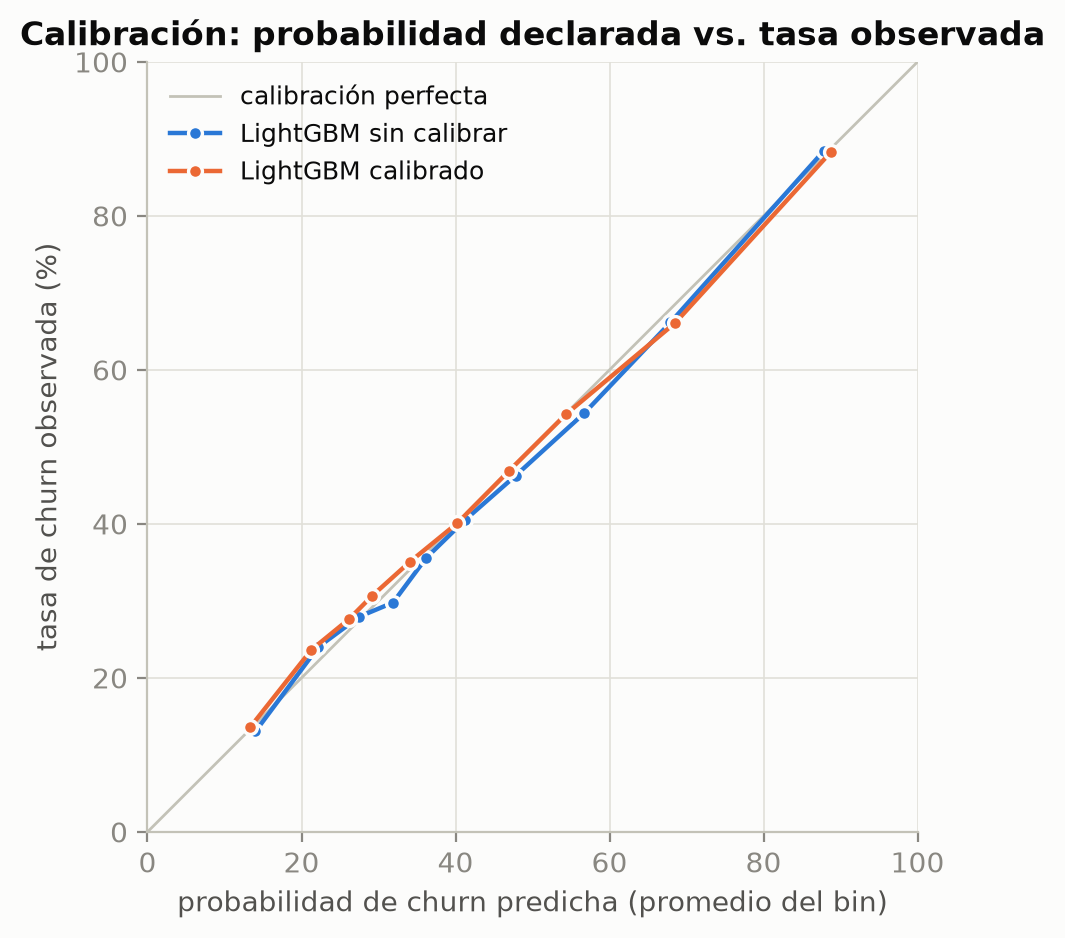

*La probabilidad declarada coincide con la tasa observada.*

In [5]:
display(Image(filename=str(ROOT / "reports/figures/modelo/calibracion.png"), width=900)); display(Markdown("*La probabilidad declarada coincide con la tasa observada.*"))

In [6]:
display(res["tables"]["LightGBM calibrado (isotónica)"]["capacity"].round(3))
display(res["tables"]["LightGBM calibrado (isotónica)"]["lift"].round(3))

,capacidad_pct,contactados,churners_capturados,recall,precision,lift,umbral_score
0,0.05,985,969,0.115,0.984,2.308,0.880
1,0.10,1971,1742,0.207,0.884,2.074,0.747
2,0.20,3942,3055,0.364,0.775,1.818,0.616
3,0.30,5913,4121,0.491,0.697,1.635,0.511
4,0.40,7884,5038,0.600,0.639,1.499,0.441
5,0.50,9854,5826,0.694,0.591,1.387,0.365


,decil,n,churners,p_medio,tasa,lift,cum_churners,cum_recall,cum_n,cum_precision,cum_lift
0,1,1971,1742.0,0.888,0.884,2.074,1742.0,0.207,1971,0.884,2.074
1,2,1971,1313.0,0.685,0.666,1.563,3055.0,0.364,3942,0.775,1.818
2,3,1971,1066.0,0.543,0.541,1.269,4121.0,0.491,5913,0.697,1.635
3,4,1971,917.0,0.469,0.465,1.092,5038.0,0.600,7884,0.639,1.499
4,5,1971,788.0,0.402,0.400,0.938,5826.0,0.694,9855,0.591,1.387
5,6,1971,703.0,0.341,0.357,0.837,6529.0,0.777,11826,0.552,1.295
6,7,1971,585.0,0.292,0.297,0.696,7114.0,0.847,13797,0.516,1.210
7,8,1971,553.0,0.262,0.281,0.658,7667.0,0.913,15768,0.486,1.141
8,9,1971,459.0,0.213,0.233,0.546,8126.0,0.967,17739,0.458,1.075
9,10,1970,274.0,0.133,0.139,0.326,8400.0,1.000,19709,0.426,1.000


## Qué explica el riesgo (SHAP global) y por qué cada vehículo (SHAP local)

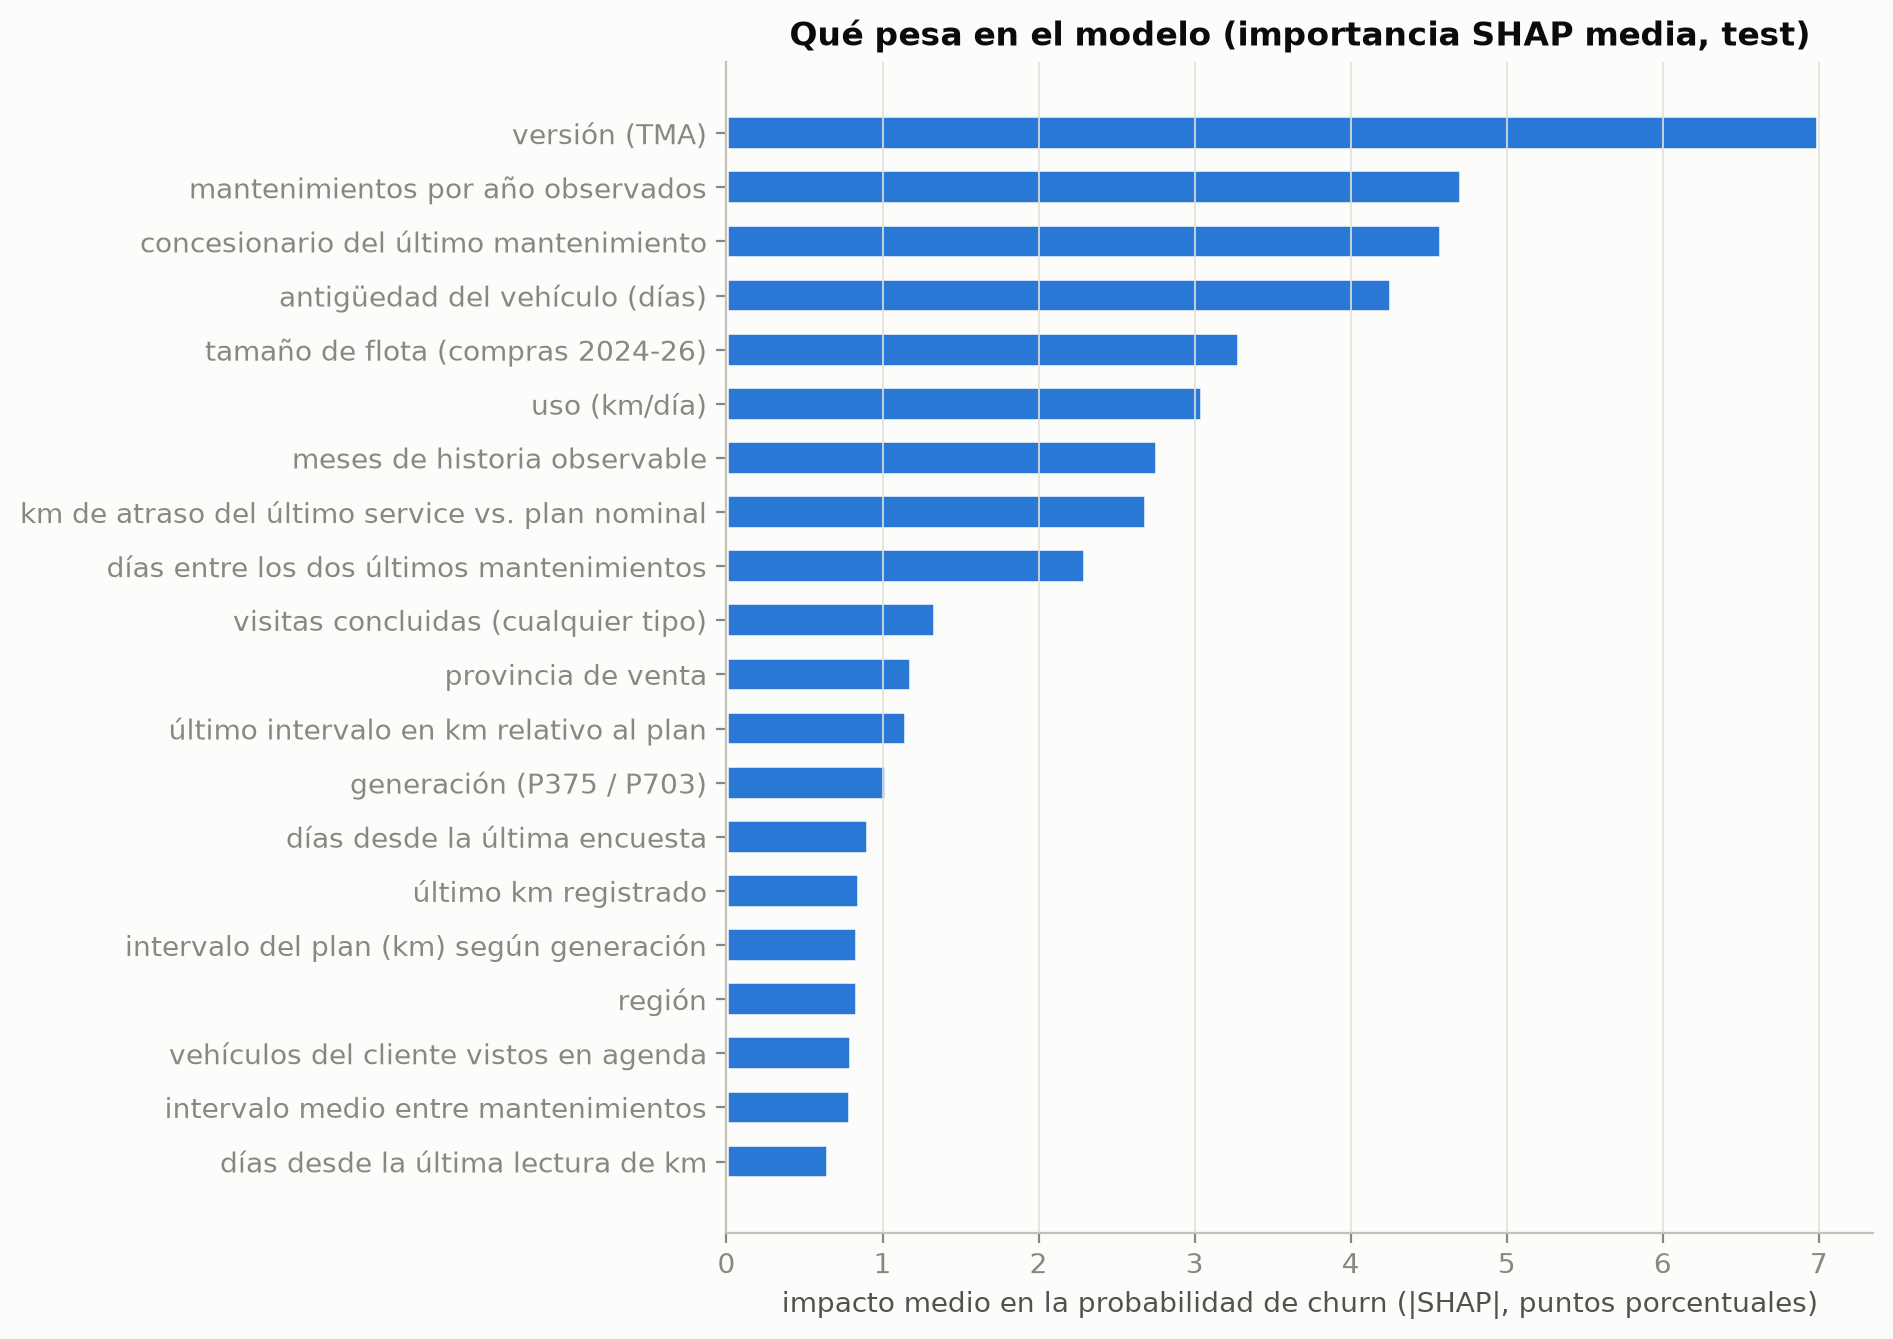

*Importancia media |SHAP| en test.*

In [7]:
display(Image(filename=str(ROOT / "reports/figures/modelo/shap_global.png"), width=900)); display(Markdown("*Importancia media |SHAP| en test.*"))

In [8]:
from repurchase.explicabilidad import shap_values, local_drivers, global_importance
X = res["X_test"].iloc[:3000]
sv = shap_values(res["booster"], X)
display(global_importance(sv, X).head(15)[["nombre", "mean_abs_shap"]])
drv = local_drivers(sv, X)
ejemplo = pd.concat([res["test_scored"].iloc[:3000][["vehicle_id", "p_lgbm_cal", LABEL]].reset_index(drop=True), drv[["driver_1", "driver_2", "driver_3"]].reset_index(drop=True)], axis=1)
display(ejemplo.sort_values("p_lgbm_cal", ascending=False).head(10))

,nombre,mean_abs_shap
0,versión (TMA),6.933319
1,mantenimientos por año observados,4.654688
2,concesionario del último mantenimiento,4.552496
3,antigüedad del vehículo (días),4.326084
4,tamaño de flota (compras 2024-26),3.258534
5,uso (km/día),3.094707
6,meses de historia observable,2.737994
7,km de atraso del último service vs. plan nominal,2.710173
8,días entre los dos últimos mantenimientos,2.245987
9,visitas concluidas (cualquier tipo),1.317989


,vehicle_id,p_lgbm_cal,label_churn,driver_1,driver_2,driver_3
358,8bb5bb6e63348755,1.0,1.0,versión (TMA) = sin registro en la red (↑ riesgo),tamaño de flota (compras 2024-26) = 472 (↑ rie...,mantenimientos por año observados = 0 (↑ riesgo)
1996,63c3ea1011b64458,1.0,1.0,versión (TMA) = sin registro en la red (↑ riesgo),tamaño de flota (compras 2024-26) = 478 (↑ rie...,mantenimientos por año observados = 0 (↑ riesgo)
1995,6357cc78571963fe,1.0,1.0,versión (TMA) = sin registro en la red (↑ riesgo),tamaño de flota (compras 2024-26) = 1 (↑ riesgo),mantenimientos por año observados = 0 (↑ riesgo)
399,ac7214d31d446ec5,1.0,1.0,"antigüedad del vehículo (días) = 4,032 (↑ riesgo)",tamaño de flota (compras 2024-26) = 1 (↑ riesgo),mantenimientos por año observados = 0.5 (↑ rie...
397,ab04ed7b2a8c6f74,1.0,1.0,versión (TMA) = sin registro en la red (↑ riesgo),tamaño de flota (compras 2024-26) = 472 (↑ rie...,mantenimientos por año observados = 0 (↑ riesgo)
396,aaa5dd2294e651d8,1.0,1.0,versión (TMA) = sin registro en la red (↑ riesgo),tamaño de flota (compras 2024-26) = 1 (↑ riesgo),mantenimientos por año observados = 0 (↑ riesgo)
388,a4b45c00b5be3c5a,1.0,1.0,versión (TMA) = sin registro en la red (↑ riesgo),tamaño de flota (compras 2024-26) = 113 (↑ rie...,mantenimientos por año observados = 0 (↑ riesgo)
1923,0ad3531c18bd3614,1.0,1.0,versión (TMA) = sin registro en la red (↑ riesgo),tamaño de flota (compras 2024-26) = 478 (↑ rie...,mantenimientos por año observados = 0 (↑ riesgo)
417,b51d4249f25c4f46,1.0,1.0,versión (TMA) = sin registro en la red (↑ riesgo),tamaño de flota (compras 2024-26) = 113 (↑ rie...,mantenimientos por año observados = 0 (↑ riesgo)
411,b390c0b4d61fb60d,1.0,1.0,versión (TMA) = sin registro en la red (↑ riesgo),tamaño de flota (compras 2024-26) = 1 (↑ riesgo),región = sin registro en la red (↑ riesgo)


## Desempeño por subgrupo (generación, primer service vs. siguientes)

In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score
te = data.loc[res["masks"][2]].reset_index(drop=True).copy(); te["p"] = res["test_scored"]["p_lgbm_cal"].values
rows = []
for col in ["generation", "anchor_type", "business_unit", "person_type"]:
    for k, g in te.groupby(col, dropna=False):
        if len(g) >= 500 and g[LABEL].nunique() == 2:
            rows.append({"grupo": f"{col} = {k}", "n": len(g), "churn": g[LABEL].mean(), "roc_auc": roc_auc_score(g[LABEL], g.p), "pr_auc": average_precision_score(g[LABEL], g.p)})
display(pd.DataFrame(rows).round(3))

,grupo,n,churn,roc_auc,pr_auc
0,generation = RANGER (P375),7216,0.529,0.708,0.709
1,generation = RANGER (P703),12458,0.365,0.723,0.657
2,anchor_type = maintenance,16147,0.416,0.722,0.639
3,anchor_type = warranty,3562,0.471,0.804,0.840
4,business_unit = Ford Blue,7336,0.338,0.717,0.636
5,business_unit = Ford Pro,3155,0.400,0.746,0.721
6,business_unit = nan,9218,0.505,0.707,0.692
7,person_type = F,5878,0.362,0.718,0.660
8,person_type = J,4521,0.343,0.738,0.662
9,person_type = nan,9224,0.505,0.707,0.692


## Segmentos accionables y ROI (supuestos explícitos en `config/negocio.json`)

In [10]:
display(pd.read_csv(ROOT / "reports/modelo/segmentos_test.csv").round(3))
display(pd.read_csv(ROOT / "reports/modelo/roi_por_capacidad.csv").round(2))

,segmento,n,p_media,tasa_churn,churners,share_churners,share,accion
0,Alto,3941,0.787,0.775,3053.0,0.363,0.2,Llamado del concesionario (asesor de service) ...
1,Medio,5913,0.472,0.469,2772.0,0.330,0.3,Recordatorio personalizado por FordPass/WhatsA...
2,Bajo,9855,0.248,0.261,2575.0,0.307,0.5,Recordatorio estándar automático (Service Remi...


,capacidad_pct,contactos,churners_alcanzados_modelo,churners_alcanzados_azar,recall_modelo,recall_azar,services_recuperados_modelo,services_recuperados_azar,valor_modelo_usd,valor_azar_usd,costo_contacto_usd,beneficio_neto_modelo_usd,beneficio_neto_azar_usd,ganancia_incremental_usd,roi_modelo
0,0.1,1971,1742,840,0.21,0.1,261.30,126.01,65325.0,31501.60,5913.0,59412.0,25588.60,33823.40,10.05
1,0.2,3942,3055,1680,0.36,0.2,458.25,252.01,114562.5,63003.20,11826.0,102736.5,51177.20,51559.30,8.69
2,0.3,5913,4121,2520,0.49,0.3,618.15,378.02,154537.5,94504.79,17739.0,136798.5,76765.79,60032.71,7.71
3,0.5,9854,5826,4200,0.69,0.5,873.90,629.97,218475.0,157492.01,29562.0,188913.0,127930.01,60982.99,6.39
